<a href="https://colab.research.google.com/github/RohanCoderiiitb/AIT-511-Machine-Learning-Assignment-1/blob/main/problem_statement_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intalling Packages

In [1]:
!pip install --upgrade pip
!pip install numpy pandas matplotlib seaborn scikit-learn torch jupyter ipykernel

In [2]:
import numpy, pandas, matplotlib, seaborn, sklearn, torch
print("numpy       :", numpy.__version__)
print("pandas      :", pandas.__version__)
print("matplotlib  :", matplotlib.__version__)
print("seaborn     :", seaborn.__version__)
print("scikit-learn:", sklearn.__version__)
print("torch       :", torch.__version__)

numpy       : 2.1.3
pandas      : 2.2.3
matplotlib  : 3.10.0
seaborn     : 0.13.2
scikit-learn: 1.6.1
torch       : 2.11.0+cpu


# Exploratory Data Analysis

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch

In [4]:
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

train_df = pd.read_csv('BT2024238_train_var1.csv')
test_df  = pd.read_csv('BT2024238_test_var1.csv')

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("\nTrain columns:", train_df.columns.tolist())
print("Test columns :", test_df.columns.tolist())

train_df.head()

Train shape: (1000, 7)
Test shape : (1000, 6)

Train columns: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'y']
Test columns : ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']


,x1,x2,x3,x4,x5,x6,y
0,-0.407897,-0.343673,-0.631026,-1.000000,1.000000,1.000000,5.257222
1,-0.542632,-1.000000,-0.570188,-1.000000,-1.000000,-0.631318,4.767247
2,-0.285437,-0.761700,-1.000000,-0.415544,1.000000,0.294311,-2.682859
3,0.451446,0.300471,0.882634,1.000000,1.000000,0.567711,-3.426659
4,-1.000000,0.030710,-0.507045,-0.754326,0.120361,-0.219641,-0.319193


In [5]:
print("=== Data types and non-null counts ===")
train_df.info()

print("\n=== Summary statistics (train) ===")
display(train_df.describe().T)

print("\n=== Missing values ===")
print("Train:\n", train_df.isna().sum())
print("Test:\n", test_df.isna().sum())

print("\n=== Duplicate rows ===")
print("Train duplicates:", train_df.duplicated().sum())
print("Test duplicates :", test_df.duplicated().sum())

=== Data types and non-null counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      1000 non-null   float64
 1   x2      1000 non-null   float64
 2   x3      1000 non-null   float64
 3   x4      1000 non-null   float64
 4   x5      1000 non-null   float64
 5   x6      1000 non-null   float64
 6   y       1000 non-null   float64
dtypes: float64(7)
memory usage: 54.8 KB

=== Summary statistics (train) ===


,count,mean,std,min,25%,50%,75%,max
x1,1000.0,0.007206,0.713601,-1.000000,-0.654613,0.017864,0.676776,1.000000
x2,1000.0,-0.003375,0.707502,-1.000000,-0.677873,0.008632,0.618492,1.000000
x3,1000.0,-0.009692,0.710685,-1.000000,-0.662142,-0.027755,0.633962,1.000000
x4,1000.0,-0.020991,0.727513,-1.000000,-0.724084,-0.030478,0.680359,1.000000
x5,1000.0,-0.066751,0.706696,-1.000000,-0.727329,-0.108410,0.557635,1.000000
x6,1000.0,-0.029889,0.700116,-1.000000,-0.640086,-0.070737,0.584567,1.000000
y,1000.0,0.889460,3.120159,-8.543755,-1.007687,0.574895,2.719467,11.422268



=== Missing values ===
Train:
 x1    0
x2    0
x3    0
x4    0
x5    0
x6    0
y     0
dtype: int64
Test:
 x1    0
x2    0
x3    0
x4    0
x5    0
x6    0
dtype: int64

=== Duplicate rows ===
Train duplicates: 0
Test duplicates : 2


Fraction of values exactly at -1 or +1 (train):
  x1: 30.5%
  x2: 29.4%
  x3: 32.0%
  x4: 32.9%
  x5: 31.0%
  x6: 29.6%

Same check on test:
  x1: 52.3%
  x2: 48.6%
  x3: 46.6%
  x4: 48.8%
  x5: 48.5%
  x6: 49.9%


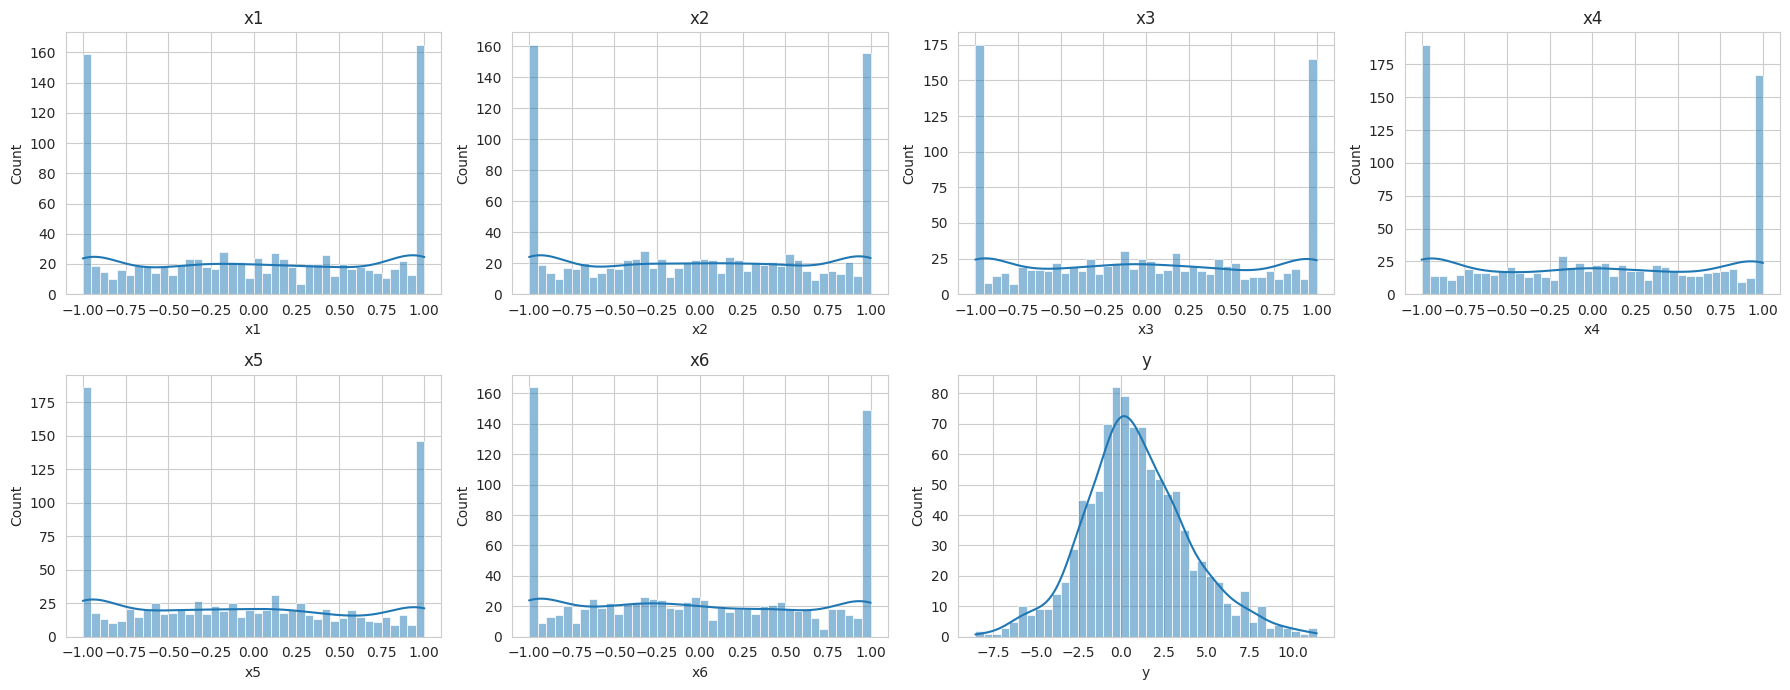

In [6]:
features = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']

print("Fraction of values exactly at -1 or +1 (train):")
for col in features:
    at_edge = ((train_df[col] == -1.0) | (train_df[col] == 1.0)).mean()
    print(f"  {col}: {at_edge:.1%}")

print("\nSame check on test:")
for col in features:
    at_edge = ((test_df[col] == -1.0) | (test_df[col] == 1.0)).mean()
    print(f"  {col}: {at_edge:.1%}")

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, col in zip(axes.ravel(), features + ['y']):
    sns.histplot(train_df[col], bins=40, kde=True, ax=ax)
    ax.set_title(col)
axes.ravel()[-1].axis('off')
plt.tight_layout()
plt.show()


IQR bounds for y: [-6.60, 8.31]  ->  25 points outside


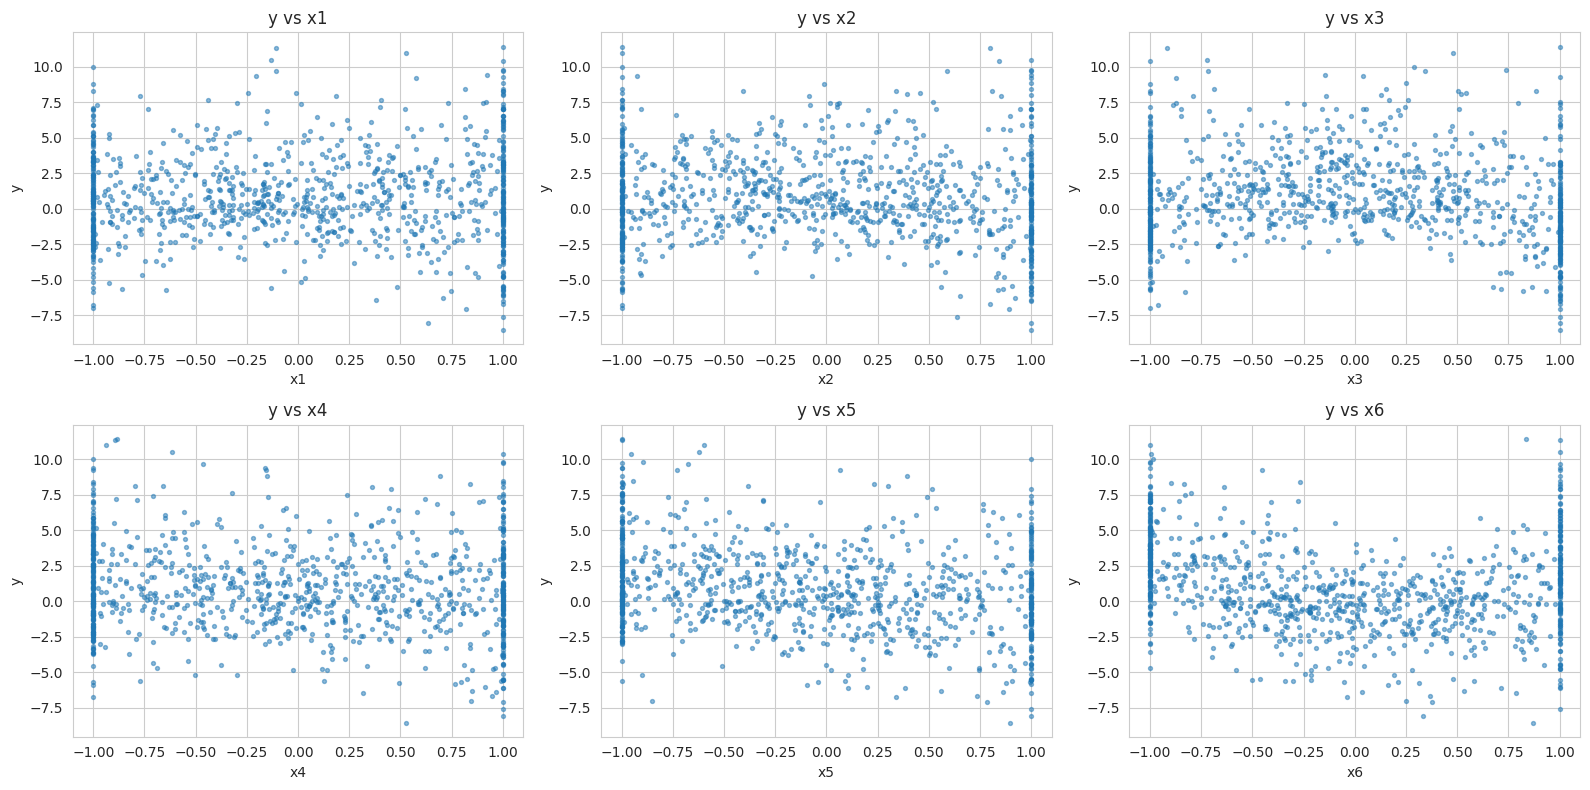

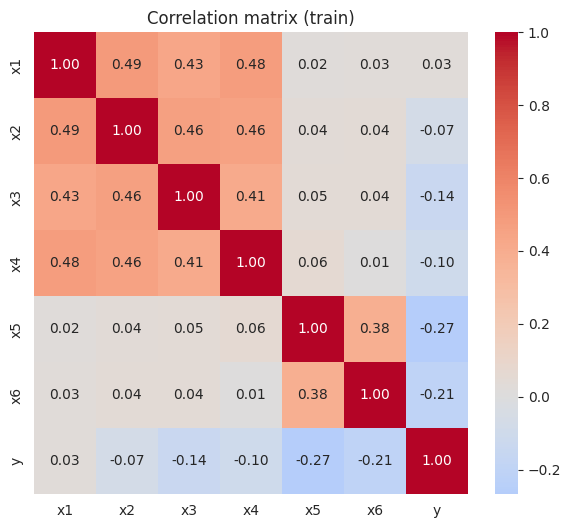

In [7]:
q1, q3 = train_df['y'].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
n_out = ((train_df['y'] < low) | (train_df['y'] > high)).sum()
print(f"IQR bounds for y: [{low:.2f}, {high:.2f}]  ->  {n_out} points outside")

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), features):
    ax.scatter(train_df[col], train_df['y'], s=8, alpha=0.5)
    ax.set_xlabel(col); ax.set_ylabel('y')
    ax.set_title(f'y vs {col}')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
sns.heatmap(train_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix (train)')
plt.show()

,train_mean,test_mean,train_std,test_std,train_min,test_min,train_max,test_max
x1,0.007,0.020,0.714,0.826,-1.0,-1.0,1.0,1.0
x2,-0.003,0.012,0.708,0.814,-1.0,-1.0,1.0,1.0
x3,-0.010,0.002,0.711,0.800,-1.0,-1.0,1.0,1.0
x4,-0.021,-0.023,0.728,0.810,-1.0,-1.0,1.0,1.0
x5,-0.067,-0.008,0.707,0.815,-1.0,-1.0,1.0,1.0
x6,-0.030,-0.003,0.700,0.822,-1.0,-1.0,1.0,1.0


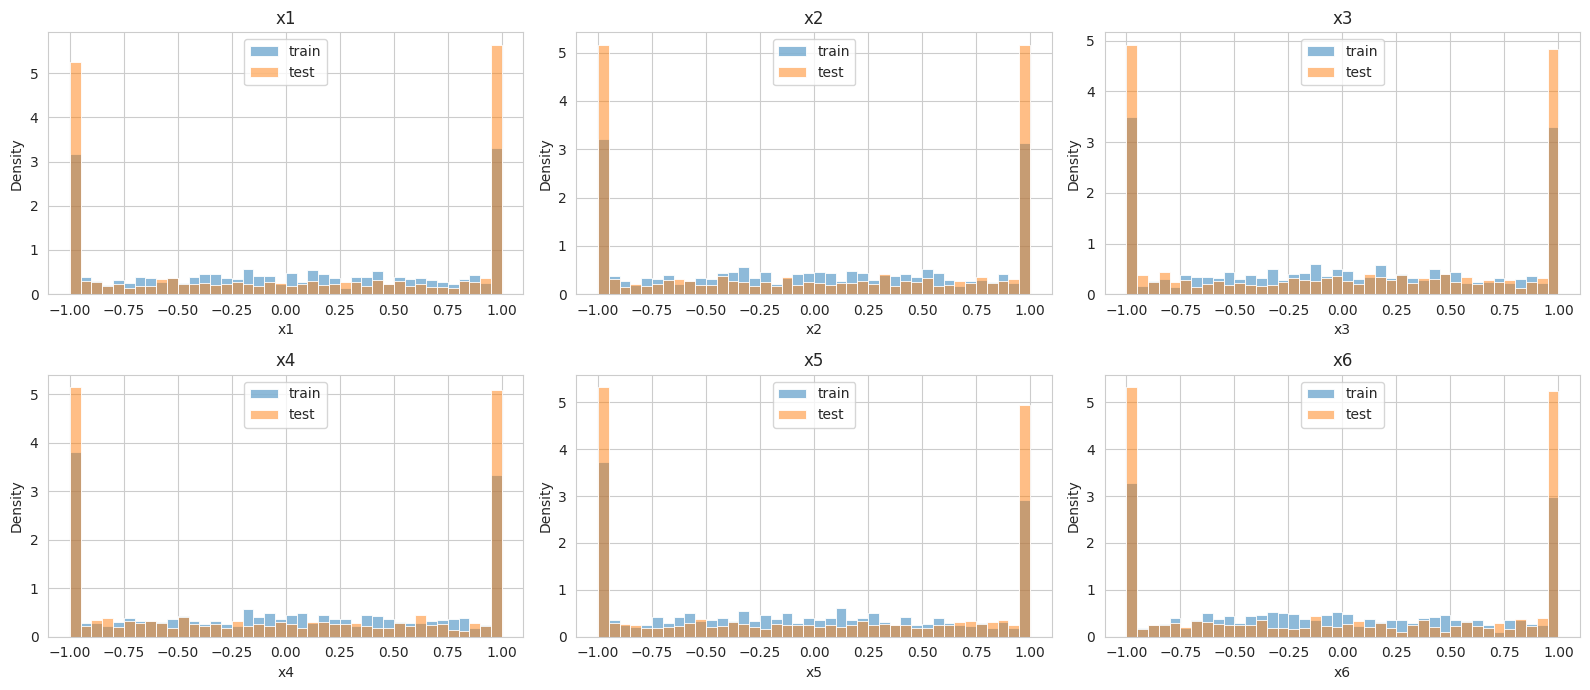

Max abs difference between train and test feature correlation matrices:
0.093


In [8]:
comparison = pd.DataFrame({
    'train_mean': train_df[features].mean(),
    'test_mean' : test_df[features].mean(),
    'train_std' : train_df[features].std(),
    'test_std'  : test_df[features].std(),
    'train_min' : train_df[features].min(),
    'test_min'  : test_df[features].min(),
    'train_max' : train_df[features].max(),
    'test_max'  : test_df[features].max(),
})
display(comparison.round(3))

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for ax, col in zip(axes.ravel(), features):
    sns.histplot(train_df[col], bins=40, stat='density', color='tab:blue',
                 alpha=0.5, label='train', ax=ax)
    sns.histplot(test_df[col], bins=40, stat='density', color='tab:orange',
                 alpha=0.5, label='test', ax=ax)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

print("Max abs difference between train and test feature correlation matrices:")
print(round((train_df[features].corr() - test_df[features].corr()).abs().max().max(), 3))

tensor([[2., 3., 4., 6., 9.]], dtype=torch.float64)
degree  1: shape (1000, 6)  formula: 6
degree  2: shape (1000, 27)  formula: 27
degree  3: shape (1000, 83)  formula: 83
degree  5: shape (1000, 461)  formula: 461
degree 10: shape (1000, 8007)  formula: 8007

Skewness of y: 0.331
Skewness of raw features:
 x1   -0.008
x2   -0.001
x3    0.024
x4    0.028
x5    0.136
x6    0.080
dtype: float64


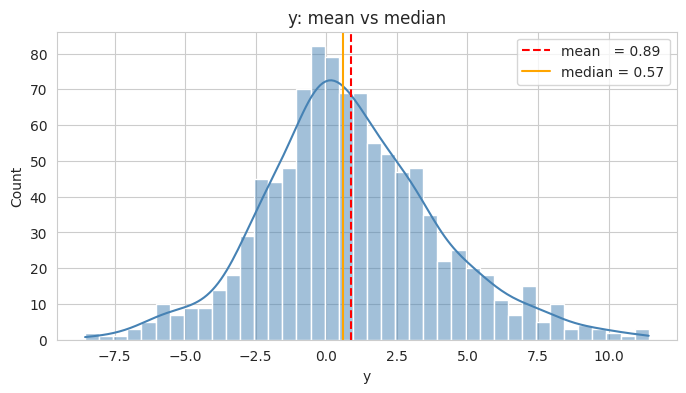

In [10]:
from itertools import combinations_with_replacement
from math import comb

X_train_raw = torch.tensor(train_df[features].values, dtype=torch.float64)
y_train     = torch.tensor(train_df['y'].values,      dtype=torch.float64).reshape(-1, 1)
X_test_raw  = torch.tensor(test_df[features].values,  dtype=torch.float64)

def poly_features(X, degree):
    """All monomials of total degree 1..degree (no constant column)."""
    n, d = X.shape
    cols = []
    for deg in range(1, degree + 1):
        for combo in combinations_with_replacement(range(d), deg):
            cols.append(X[:, list(combo)].prod(dim=1))
    return torch.stack(cols, dim=1)

print(poly_features(torch.tensor([[2., 3.]], dtype=torch.float64), 2))

for d in [1, 2, 3, 5, 10]:
    out = poly_features(X_train_raw, d)
    print(f"degree {d:2d}: shape {tuple(out.shape)}  formula: {comb(d + 6, 6) - 1}")

print("\nSkewness of y:", train_df['y'].skew().round(3))
print("Skewness of raw features:\n", train_df[features].skew().round(3))

plt.figure(figsize=(8, 4))
sns.histplot(train_df['y'], bins=40, kde=True, color='steelblue')
plt.axvline(train_df['y'].mean(),   color='red',    linestyle='--', label=f"mean   = {train_df['y'].mean():.2f}")
plt.axvline(train_df['y'].median(), color='orange', linestyle='-',  label=f"median = {train_df['y'].median():.2f}")
plt.legend()
plt.title('y: mean vs median')
plt.show()


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
F_scaled = torch.tensor(scaler.fit_transform(F_all.numpy()))

print("Shape:", F_scaled.shape)
print("max |column mean|:", F_scaled.mean(dim=0).abs().max().item())
print("column std min/max:", F_scaled.std(dim=0).min().item(), F_scaled.std(dim=0).max().item())

Shape: torch.Size([1000, 461])
max |column mean|: 1.1439738045737613e-15
column std min/max: 1.0005003753127704 1.0005003753127768


# Model Selection

In [20]:
from math import comb

K_FOLDS = 5
degrees = list(range(1, 11))
lams    = [float(l) for l in np.logspace(-4, 2, 25)]

F_full = poly_features(X_train_raw, 10)
n_cols = {d: comb(d + 6, 6) - 1 for d in degrees}

n = X_train_raw.shape[0]
g = torch.Generator().manual_seed(RANDOM_SEED)
perm  = torch.randperm(n, generator=g)
folds = torch.chunk(perm, K_FOLDS)

cv_mse = torch.zeros(len(degrees), len(lams), K_FOLDS, dtype=torch.float64)

for k in range(K_FOLDS):
    va_idx = folds[k]
    tr_idx = torch.cat([folds[j] for j in range(K_FOLDS) if j != k])

    scaler = StandardScaler()
    Ftr = torch.tensor(scaler.fit_transform(F_full[tr_idx].numpy()))
    Fva = torch.tensor(scaler.transform(F_full[va_idx].numpy()))
    ytr, yva = y_train[tr_idx], y_train[va_idx]

    y_mu = ytr.mean()
    yc   = ytr - y_mu
    n_tr = Ftr.shape[0]

    for i, d in enumerate(degrees):
        A, B = Ftr[:, :n_cols[d]], Fva[:, :n_cols[d]]
        K    = A @ A.T
        Kva  = B @ A.T
        e, U = torch.linalg.eigh(K)
        Uty  = U.T @ yc

        for j, lam in enumerate(lams):
            alpha = U @ (Uty / (e.unsqueeze(1) + n_tr * lam))
            pred  = Kva @ alpha + y_mu
            cv_mse[i, j, k] = ((yva - pred) ** 2).mean()

cv_mean = cv_mse.mean(dim=2)
cv_std  = cv_mse.std(dim=2)

print(f"Baseline (always predict the mean): MSE ~ {y_train.var().item():.3f}\n")

print(f"{'degree':>6} | {'best lambda':>11} | {'CV MSE':>8} | {'std over folds':>14}")
for ii, d in enumerate(degrees):
    jj = cv_mean[ii].argmin().item()
    print(f"{d:6d} | {lams[jj]:11.5f} | {cv_mean[ii, jj]:8.4f} | {cv_std[ii, jj]:14.4f}")

i, j = divmod(cv_mean.argmin().item(), len(lams))
print(f"\nOverall best: degree {degrees[i]}, lambda {lams[j]:.5f}  ->  "
      f"CV MSE {cv_mean[i, j]:.4f} +/- {cv_std[i, j]:.4f}")


Baseline (always predict the mean): MSE ~ 9.735

degree | best lambda |   CV MSE | std over folds
     1 |     0.03162 |   8.6479 |         0.4433
     2 |     0.01778 |   2.6781 |         0.2862
     3 |     0.00562 |   0.8913 |         0.1176
     4 |     0.01000 |   0.7016 |         0.1427
     5 |     0.03162 |   0.5174 |         0.0959
     6 |     0.03162 |   0.6021 |         0.0896
     7 |     0.10000 |   0.6319 |         0.0702
     8 |     0.10000 |   0.7546 |         0.0855
     9 |     0.31623 |   0.8839 |         0.1591
    10 |     0.17783 |   1.0017 |         0.1180

Overall best: degree 5, lambda 0.03162  ->  CV MSE 0.5174 +/- 0.0959


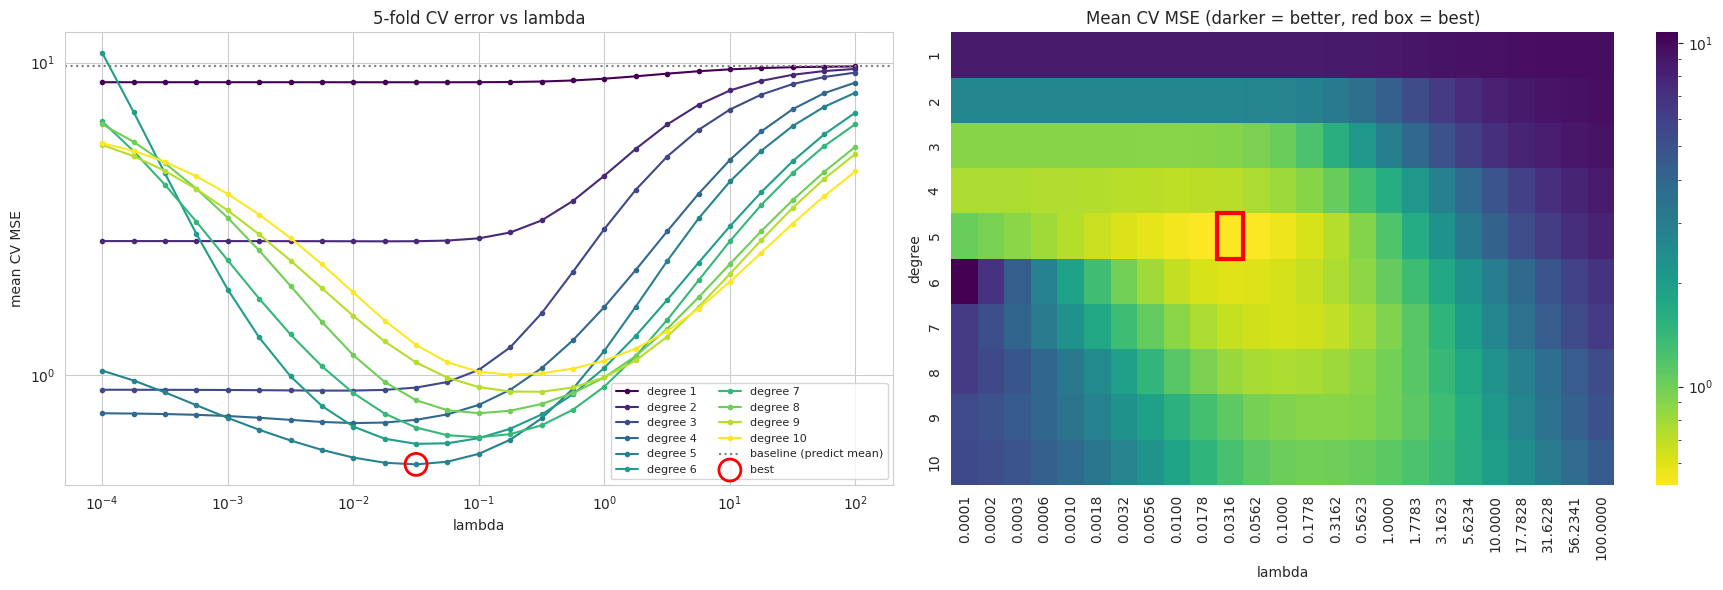

In [21]:
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
cmap = plt.cm.viridis(np.linspace(0, 1, len(degrees)))
for ii, d in enumerate(degrees):
    ax.plot(lams, cv_mean[ii].numpy(), marker='o', markersize=3, color=cmap[ii], label=f'degree {d}')
ax.axhline(y_train.var().item(), color='gray', linestyle=':', label='baseline (predict mean)')
ax.scatter(lams[j], cv_mean[i, j].item(), s=250, facecolors='none',
           edgecolors='red', linewidths=2, zorder=5, label='best')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('lambda'); ax.set_ylabel('mean CV MSE')
ax.set_title(f'{K_FOLDS}-fold CV error vs lambda')
ax.legend(fontsize=8, ncol=2)

ax = axes[1]
sns.heatmap(cv_mean.numpy(), cmap='viridis_r', norm=LogNorm(), annot=False,
            xticklabels=[f'{l:.4f}' for l in lams], yticklabels=degrees, ax=ax)
ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='red', linewidth=3))
ax.set_xlabel('lambda'); ax.set_ylabel('degree')
ax.set_title('Mean CV MSE (darker = better, red box = best)')
plt.setp(ax.get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()


# Training the Model

In [24]:
DEG = 5
LAM = 10 ** -1.5

def ridge_train(F, y, lam):
    """Closed-form ridge on scaled features. Returns weights w and intercept b (bias not penalised)."""
    m, p = F.shape
    F_mu, y_mu = F.mean(dim=0, keepdim=True), y.mean()
    Fc, yc = F - F_mu, y - y_mu
    w = torch.linalg.solve(Fc.T @ Fc / m + lam * torch.eye(p, dtype=F.dtype), Fc.T @ yc / m)
    return w, y_mu - F_mu @ w

F_all = poly_features(X_train_raw, DEG)
F_te  = poly_features(X_test_raw,  DEG)

scaler = StandardScaler()
F_tr_s = torch.tensor(scaler.fit_transform(F_all.numpy()))
F_te_s = torch.tensor(scaler.transform(F_te.numpy()))

y_mu, y_sd = y_train.mean(), y_train.std()
y_s = (y_train - y_mu) / y_sd

w_gd, b_gd, hist = train_ridge_gd(F_tr_s, y_s, LAM, epochs=50000)
test_pred = (F_te_s @ w_gd + b_gd) * y_sd + y_mu

w_cf, b_cf = ridge_train(F_tr_s, y_train, LAM)
test_pred_cf = F_te_s @ w_cf + b_cf
print("max |GD prediction - exact prediction| on test:", (test_pred - test_pred_cf).abs().max().item())

train_pred = (F_tr_s @ w_gd + b_gd) * y_sd + y_mu
train_mse = ((y_train - train_pred) ** 2).mean().item()
train_r2  = 1 - ((y_train - train_pred) ** 2).sum().item() / ((y_train - y_train.mean()) ** 2).sum().item()
jj = int(np.argmin([abs(l - LAM) for l in lams]))
print(f"\nTrain MSE {train_mse:.4f}  R2 {train_r2:.4f}  |  CV MSE estimate {cv_mean[DEG - 1, jj]:.4f}")

print("\nTest predictions vs training y:")
print(pd.DataFrame({'train y': y_train.flatten().numpy(),
                    'test pred': test_pred.flatten().numpy()}).describe().T.round(3))


largest eigenvalue of F^T F / n = 67.51  ->  lr used = 0.01332
max |GD prediction - exact prediction| on test: 5.098144129078719e-13

Train MSE 0.2019  R2 0.9792  |  CV MSE estimate 0.5174

Test predictions vs training y:
            count   mean    std     min    25%    50%    75%     max
train y    1000.0  0.889  3.120  -8.544 -1.008  0.575  2.719  11.422
test pred  1000.0  1.279  4.242 -10.594 -1.460  1.252  3.892  15.863


In [25]:
DEG = 5
LAM = 10 ** -1.5
n = X_train_raw.shape[0]

def ridge_train(F, y, lam):
    """Closed-form ridge on scaled features. Returns weights w and intercept b (bias not penalised)."""
    m, p = F.shape
    F_mu, y_mu = F.mean(dim=0, keepdim=True), y.mean()
    Fc, yc = F - F_mu, y - y_mu
    w = torch.linalg.solve(Fc.T @ Fc / m + lam * torch.eye(p, dtype=F.dtype), Fc.T @ yc / m)
    return w, y_mu - F_mu @ w

F_all = poly_features(X_train_raw, DEG)

g = torch.Generator().manual_seed(RANDOM_SEED)
folds = torch.chunk(torch.randperm(n, generator=g), 5)
oof = torch.zeros(n, 1, dtype=torch.float64)
for f in range(5):
    va = folds[f]
    tr = torch.cat([folds[j] for j in range(5) if j != f])
    sc = StandardScaler()
    F_tr = torch.tensor(sc.fit_transform(F_all[tr].numpy()))
    F_va = torch.tensor(sc.transform(F_all[va].numpy()))
    w, b = ridge_train(F_tr, y_train[tr], LAM)
    oof[va] = F_va @ w + b

sq_err = ((y_train - oof) ** 2).flatten()
print(f"Overall out-of-fold MSE: {sq_err.mean():.4f}   (should match the CV estimate ~0.52)\n")

clip_tr = (X_train_raw.abs() == 1).sum(dim=1).clamp(max=4)
clip_te = (X_test_raw.abs()  == 1).sum(dim=1).clamp(max=4)

rows, reweighted = [], 0.0
for k in range(5):
    m_tr, m_te = clip_tr == k, clip_te == k
    mse_k = sq_err[m_tr].mean().item() if m_tr.sum() > 0 else float('nan')
    rows.append({'clipped features': f'{k}' if k < 4 else '4+',
                 'train rows %': 100 * m_tr.float().mean().item(),
                 'test rows %' : 100 * m_te.float().mean().item(),
                 'OOF MSE'     : mse_k})
    if m_tr.sum() > 0:
        reweighted += m_te.float().mean().item() * mse_k
display(pd.DataFrame(rows).round(3))
print(f"MSE reweighted to the test set's mix of rows: {reweighted:.4f}")

g2 = torch.Generator().manual_seed(123)
perm = torch.randperm(n, generator=g2)
ho_va, ho_tr = perm[:200], perm[200:]

sc = StandardScaler()
F_a = torch.tensor(sc.fit_transform(F_all[ho_tr].numpy()))
F_b = torch.tensor(sc.transform(F_all[ho_va].numpy()))
w, b = ridge_train(F_a, y_train[ho_tr], LAM)

def mse_r2(y_true, y_pred):
    return (((y_true - y_pred) ** 2).mean().item(),
            1 - ((y_true - y_pred) ** 2).sum().item() / ((y_true - y_true.mean()) ** 2).sum().item())

mse_tr, r2_tr = mse_r2(y_train[ho_tr], F_a @ w + b)
mse_ho, r2_ho = mse_r2(y_train[ho_va], F_b @ w + b)
print(f"\nHold-out (trained on 800, scored on 200):")
print(f"  train part: MSE {mse_tr:.4f}  R2 {r2_tr:.4f}")
print(f"  hold-out  : MSE {mse_ho:.4f}  R2 {r2_ho:.4f}")


Overall out-of-fold MSE: 0.5174   (should match the CV estimate ~0.52)



,clipped features,train rows %,test rows %,OOF MSE
0,0,12.6,1.6,0.386
1,1,28.5,10.4,0.452
2,2,30.5,23.5,0.421
3,3,19.3,32.3,0.651
4,4+,9.1,32.2,0.944


MSE reweighted to the test set's mix of rows: 0.6666

Hold-out (trained on 800, scored on 200):
  train part: MSE 0.1832  R2 0.9809
  hold-out  : MSE 0.5072  R2 0.9501


In [27]:
DEG = 5
LAM = 10 ** -1.5

def ridge_train(F, y, lam):
    """Closed-form ridge on scaled features. Returns weights w and intercept b (bias not penalised)."""
    m, p = F.shape
    F_mu, y_mu_ = F.mean(dim=0, keepdim=True), y.mean()
    Fc, yc = F - F_mu, y - y_mu_
    w = torch.linalg.solve(Fc.T @ Fc / m + lam * torch.eye(p, dtype=F.dtype), Fc.T @ yc / m)
    return w, y_mu_ - F_mu @ w

# Refit on all 1000 rows (fresh scaler, so earlier cells can't interfere)
F_tr = poly_features(X_train_raw, DEG)
sc = StandardScaler().fit(F_tr.numpy())
F_tr_s = torch.tensor(sc.transform(F_tr.numpy()))
w, b = ridge_train(F_tr_s, y_train, LAM)               # w: (461, 1), b: (1,)

# Name each column, in the same order poly_features builds them
names, degs = [], []
for deg in range(1, DEG + 1):
    for combo in combinations_with_replacement(range(6), deg):
        counts = {}
        for idx in combo:
            counts[idx + 1] = counts.get(idx + 1, 0) + 1
        names.append('*'.join(f'x{i}' + (f'^{p}' if p > 1 else '') for i, p in sorted(counts.items())))
        degs.append(deg)

# Undo the scaling: coefficients on the raw monomials
mu = torch.tensor(sc.mean_).reshape(-1, 1)
s  = torch.tensor(sc.scale_).reshape(-1, 1)
coef      = (w / s).flatten()                          # raw coefficient of each monomial
intercept = (b - (w * mu / s).sum()).item()

table = pd.DataFrame({'term': names, 'degree': degs,
                      'weight (scaled)': w.flatten().numpy(),
                      'coefficient (raw)': coef.numpy()})
table['|weight|'] = table['weight (scaled)'].abs()
table = table.sort_values('|weight|', ascending=False)

print(f"{len(table)} terms, intercept = {intercept:.4f}\n")
print("Top 20 terms by |scaled weight|:")
display(table.head(20).drop(columns='|weight|').round(4))

print("\nTotal |scaled weight| by degree:")
print(table.groupby('degree')['|weight|'].sum().round(3))

# The model as an equation (top 10 terms shown)
top = table.head(10)
expr = f"y = {intercept:.4f}" + ''.join(f" {c:+.4f}*{t}" for t, c in zip(top['term'], top['coefficient (raw)']))
print("\n" + expr + f" + ... ({len(table) - 10} more terms)")

# Check: predictions from the raw coefficients must equal the saved test predictions
F_te = poly_features(X_test_raw, DEG)
pred_raw = F_te @ coef.reshape(-1, 1) + intercept
print("\nmax |raw-coefficient prediction - test_pred|:", (pred_raw - test_pred).abs().max().item())

table.drop(columns='|weight|').to_csv('model_weights_var1.csv', index=False)   # full list of all 461 terms


461 terms, intercept = 0.1218

Top 20 terms by |scaled weight|:


,term,degree,weight (scaled),coefficient (raw)
10,x1*x5,2,-0.6888,-1.3956
140,x2^3*x3,4,-0.6302,-1.5018
26,x6^2,2,0.5605,1.4033
20,x3*x6,2,-0.4700,-0.9485
208,x6^4,4,0.4438,1.0274
414,x3^3*x6^2,5,-0.4064,-1.0386
309,x1*x3^2*x6^2,5,-0.3790,-1.2575
178,x3^2*x4^2,4,-0.3474,-1.0070
87,x1^3*x5,4,-0.3290,-0.7709
274,x1*x2^2*x4^2,5,0.3273,1.0028



Total |scaled weight| by degree:
degree
1     0.289
2     2.656
3     2.838
4     8.160
5    11.885
Name: |weight|, dtype: float64

y = 0.1218 -1.3956*x1*x5 -1.5018*x2^3*x3 +1.4033*x6^2 -0.9485*x3*x6 +1.0274*x6^4 -1.0386*x3^3*x6^2 -1.2575*x1*x3^2*x6^2 -1.0070*x3^2*x4^2 -0.7709*x1^3*x5 +1.0028*x1*x2^2*x4^2 + ... (451 more terms)

max |raw-coefficient prediction - test_pred|: 5.093703236980218e-13


# Saving the Predictions

In [28]:
out = test_df.copy()
out['y'] = test_pred.flatten().numpy()
out.to_csv('BT2024238_pred_var1.csv', index=False)

chk = pd.read_csv('BT2024238_pred_var1.csv')
print("shape:", chk.shape, "| columns:", chk.columns.tolist())
print("NaNs:", chk.isna().sum().sum())
print("same rows as test file:", (chk[features].values == test_df[features].values).all())
chk.head()

shape: (1000, 7) | columns: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'y']
NaNs: 0
same rows as test file: True


,x1,x2,x3,x4,x5,x6,y
0,0.421618,0.831043,1.000000,0.858409,0.906848,-0.415071,-3.988355
1,-1.000000,-1.000000,-0.474562,-0.595165,0.552993,-0.830375,3.834505
2,-1.000000,0.544189,-0.362349,0.915530,-0.872857,-1.000000,1.329268
3,0.426574,1.000000,0.130039,0.843409,1.000000,-0.455790,-0.733056
4,1.000000,0.708809,0.486187,0.645780,0.518907,-0.599798,0.238456
